# MSK-Chord Data Extraction

### Plan
* Static data extraction and filtering,
* Longitudinal data extraction with patient filtering,
* Data validation and consistency checks,
* Final dataset creation

###  Imports and Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

### Utility Functions

In [2]:
def extract_patient_id(df, key):
    """Extract numeric patient ID from P-XXX format"""
    df[key] = df[key].str.extract(r'P-(\d+)')
    df[key] = pd.to_numeric(df[key], errors='coerce')
    return df.sort_values(by=[key])

def extract_patient_id_two_keys(df, key1, key2):
    """Extract numeric patient ID and sort by two keys"""
    df[key1] = df[key1].str.extract(r'P-(\d+)')
    df[key1] = pd.to_numeric(df[key1], errors='coerce')
    return df.sort_values(by=[key1, key2])

def validate_patient_consistency(static_patients, long_patients, stage_name):
    """Validate patient consistency between datasets"""
    print(f"\n=== {stage_name} ===")
    print(f"Static patients: {len(static_patients)}")
    print(f"Longitudinal patients: {len(long_patients)}")
    
    # Check for patients in longitudinal but not in static
    extra_in_long = set(long_patients) - set(static_patients)
    if extra_in_long:
        print(f"⚠️  {len(extra_in_long)} patients in longitudinal data but not in static data")
        
    # Check for patients in static but not in longitudinal
    missing_in_long = set(static_patients) - set(long_patients)
    if missing_in_long:
        print(f"⚠️  {len(missing_in_long)} patients in static data but not in longitudinal data")
        
    # Common patients
    common_patients = set(static_patients) & set(long_patients)
    print(f"✅ Common patients: {len(common_patients)}")
    
    return list(common_patients)

### Configuration

In [3]:
# Configuration
CANCER_TYPE = "PROSTATE"  # Change this to target different cancer types
print(f"Target cancer type: {CANCER_TYPE}")

# Data paths
base_path = "/path/to/HyperNSDE/datasets/MSK-Chord/original_data_files/"
patient_file = base_path + "data_clinical_patient.txt"
diagnosis_file = base_path + "data_timeline_diagnosis.txt"
ca15_file = base_path + "data_timeline_ca_15-3_labs.txt"
ca19_file = base_path + "data_timeline_ca_19-9_labs.txt"
psa_file = base_path + "data_timeline_psa_labs.txt"
cea_file = base_path + "data_timeline_cea_labs.txt"

Target cancer type: PROSTATE


### Load and Process Static Data

In [4]:
# Load patient data
df_patients = pd.read_csv(patient_file, sep='\t')
df_patients = df_patients[4:]  # Skip header rows

print("=== Static Data Processing ===")
print(f"Raw patient data shape: {df_patients.shape}")

# Process patient IDs
df_patients = extract_patient_id(df_patients, "#Patient Identifier")
df_patients = df_patients.rename(columns={"#Patient Identifier": 'PATIENT_ID'})

# Get unique patients
reference_patients = df_patients["PATIENT_ID"].unique()
print(f"Unique patients: {len(reference_patients)}")

# Set index
df_patients = df_patients.set_index('PATIENT_ID')
df_patients.head()

=== Static Data Processing ===
Raw patient data shape: (24950, 26)
Unique patients: 24950


,Sex,Race,Ethnicity,Current Age,Stage (Highest Recorded),Number of Tumor Registry Entries,Tumor Site: Adrenal Glands (NLP),Tumor Site: Bone (NLP),Tumor Site: CNS/Brain (NLP),Tumor Site: Intra Abdominal,...,Tumor Site: Reproductive Organs (NLP),Smoking History (NLP),"Gleason Score, 1st Reported (NLP)","Gleason Score, Highest Reported (NLP)",History for Positive PD-L1 (NLP),Prior Treatment to MSK (NLP),Overall Survival (Months),Overall Survival Status,HR,HER2
PATIENT_ID,,,,,,,,,,,,,,,,,,,,,
12,Female,White,Non-Spanish; Non-Hispanic,68,Stage 1-3,2,No,No,No,Yes,...,No,Former/Current Smoker,NaN,NaN,No,Unknown,118.4546647,0:LIVING,No,No
15,Female,White,Non-Spanish; Non-Hispanic,45,Stage 1-3,1,No,Yes,Yes,No,...,No,Unknown,NaN,NaN,NaN,Unknown,13.90683407,1:DECEASED,Yes,No
36,Female,Other,Non-Spanish; Non-Hispanic,68,Stage 4,1,No,Yes,No,No,...,No,Never,NaN,NaN,NaN,Unknown,115.4628872,0:LIVING,NaN,NaN
41,Female,White,Non-Spanish; Non-Hispanic,53,Stage 1-3,1,No,Yes,Yes,No,...,No,Unknown,NaN,NaN,NaN,Prior medications to MSK,13.61094399,1:DECEASED,No,No
57,Female,White,Non-Spanish; Non-Hispanic,43,Stage 4,1,No,Yes,Yes,Yes,...,Yes,Never,NaN,NaN,No,Unknown,29.62188535,1:DECEASED,Yes,No


### Process Categorical Variables

In [5]:
# Define categorical variables
categorical_vars = [
    'Sex', 'Race', 'Ethnicity', 'Stage (Highest Recorded)', 
    'Tumor Site: Adrenal Glands (NLP)', 'Tumor Site: Bone (NLP)', 
    'Tumor Site: CNS/Brain (NLP)', 'Tumor Site: Intra Abdominal', 
    'Tumor Site: Liver (NLP)', 'Tumor Site: Lung (NLP)',
    'Tumor Site: Lymph Node (NLP)', 'Tumor Site: Other (NLP)', 
    'Tumor Site: Pleura (NLP)', 'Tumor Site: Reproductive Organs (NLP)', 
    'Smoking History (NLP)', 'History for Positive PD-L1 (NLP)', 
    'Prior Treatment to MSK (NLP)', 'Overall Survival Status', 
    'HR', 'HER2'
]

# Process categorical variables
original_cat_values = []
for col in categorical_vars:
    if col in df_patients.columns:
        df_patients[col] = df_patients[col].replace([
            'Unknown', 'No Value Entered', 'Pt Refused To Answer', 
            'Unknown whether Spanish or not'
        ], np.nan)
        original_cat_values.append(pd.unique(df_patients[col]))
        df_patients[col] = df_patients[col].astype('category').cat.codes
        df_patients[col] = df_patients[col].replace(-1, np.nan)

print(f"Categorical variables processed: {len([col for col in categorical_vars if col in df_patients.columns])}")
df_patients.head()

Categorical variables processed: 20


,Sex,Race,Ethnicity,Current Age,Stage (Highest Recorded),Number of Tumor Registry Entries,Tumor Site: Adrenal Glands (NLP),Tumor Site: Bone (NLP),Tumor Site: CNS/Brain (NLP),Tumor Site: Intra Abdominal,...,Tumor Site: Reproductive Organs (NLP),Smoking History (NLP),"Gleason Score, 1st Reported (NLP)","Gleason Score, Highest Reported (NLP)",History for Positive PD-L1 (NLP),Prior Treatment to MSK (NLP),Overall Survival (Months),Overall Survival Status,HR,HER2
PATIENT_ID,,,,,,,,,,,,,,,,,,,,,
12,0.0,5.0,3.0,68,0.0,2,0.0,0.0,0.0,1.0,...,0.0,0.0,NaN,NaN,0.0,NaN,118.4546647,0,0.0,0.0
15,0.0,5.0,3.0,45,0.0,1,0.0,1.0,1.0,0.0,...,0.0,NaN,NaN,NaN,NaN,NaN,13.90683407,1,1.0,0.0
36,0.0,4.0,3.0,68,1.0,1,0.0,1.0,0.0,0.0,...,0.0,1.0,NaN,NaN,NaN,NaN,115.4628872,0,NaN,NaN
41,0.0,5.0,3.0,53,0.0,1,0.0,1.0,1.0,0.0,...,0.0,NaN,NaN,NaN,NaN,1.0,13.61094399,1,0.0,0.0
57,0.0,5.0,3.0,43,1.0,1,0.0,1.0,1.0,1.0,...,1.0,1.0,NaN,NaN,0.0,NaN,29.62188535,1,1.0,0.0


### Define Static Data Types

In [6]:
# Define static data types
# static_types = {var: ("real", 1, 1) for var in df_patients.columns}
static_types = {}

# Set categorical variables
for var in categorical_vars:
    if var in df_patients.columns:
        unique_vals = df_patients[var].dropna().unique()
        print(unique_vals)
        static_types[var] = ("cat", len(unique_vals), 1)

# Define real variables
real_vars = [
    'Current Age', 'Number of Tumor Registry Entries', 
    'Gleason Score, 1st Reported (NLP)', 
    'Gleason Score, Highest Reported (NLP)', 
    'Overall Survival (Months)'
]

for var in real_vars:
    if var in df_patients.columns:
        static_types[var] = ("real", 1, 1)

print("Static data types defined")
static_types

[0. 1.]
[5. 4. 0. 1. 2. 3.]
[3. 1. 7. 6. 5. 2. 0. 4. 8.]
[0. 1.]
[0. 1.]
[0. 1.]
[0. 1.]
[1. 0.]
[0. 1.]
[1. 0.]
[1. 0.]
[1. 0.]
[0. 1.]
[0. 1.]
[0. 1.]
[0. 1.]
[1. 0.]
[0 1]
[0. 1.]
[0. 1.]
Static data types defined


{'Sex': ('cat', 2, 1),
 'Race': ('cat', 6, 1),
 'Ethnicity': ('cat', 9, 1),
 'Stage (Highest Recorded)': ('cat', 2, 1),
 'Tumor Site: Adrenal Glands (NLP)': ('cat', 2, 1),
 'Tumor Site: Bone (NLP)': ('cat', 2, 1),
 'Tumor Site: CNS/Brain (NLP)': ('cat', 2, 1),
 'Tumor Site: Intra Abdominal': ('cat', 2, 1),
 'Tumor Site: Liver (NLP)': ('cat', 2, 1),
 'Tumor Site: Lung (NLP)': ('cat', 2, 1),
 'Tumor Site: Lymph Node (NLP)': ('cat', 2, 1),
 'Tumor Site: Other (NLP)': ('cat', 2, 1),
 'Tumor Site: Pleura (NLP)': ('cat', 2, 1),
 'Tumor Site: Reproductive Organs (NLP)': ('cat', 2, 1),
 'Smoking History (NLP)': ('cat', 2, 1),
 'History for Positive PD-L1 (NLP)': ('cat', 2, 1),
 'Prior Treatment to MSK (NLP)': ('cat', 2, 1),
 'Overall Survival Status': ('cat', 2, 1),
 'HR': ('cat', 2, 1),
 'HER2': ('cat', 2, 1),
 'Current Age': ('real', 1, 1),
 'Number of Tumor Registry Entries': ('real', 1, 1),
 'Gleason Score, 1st Reported (NLP)': ('real', 1, 1),
 'Gleason Score, Highest Reported (NLP)': ('re

### Load and Process Diagnosis Data

In [7]:
# Load diagnosis data
df_diagnosis = pd.read_csv(diagnosis_file, sep="\t")
print(f"Diagnosis data shape: {df_diagnosis.shape}")

# Extract cancer type and location
df_diagnosis['type'] = None
df_diagnosis['loc'] = None
df_diagnosis[['type', 'loc']] = df_diagnosis['DX_DESCRIPTION'].str.split('|', n=1, expand=True)

# Process patient IDs
df_diagnosis = extract_patient_id_two_keys(df_diagnosis, 'PATIENT_ID', 'START_DATE')
df_diagnosis = df_diagnosis[["PATIENT_ID", 'START_DATE', 'type', 'loc']]

# Merge with patient data
# df_patients = df_patients.reset_index()
print(df_patients.shape)
df_patients = pd.merge(df_patients, df_diagnosis, on=['PATIENT_ID'], how='left')
# df_patients = df_patients.set_index('PATIENT_ID')

print(f"Patient data after diagnosis merge: {df_patients.shape}")
df_patients.head()

Diagnosis data shape: (25145, 12)
(24950, 25)
Patient data after diagnosis merge: (25155, 29)


,PATIENT_ID,Sex,Race,Ethnicity,Current Age,Stage (Highest Recorded),Number of Tumor Registry Entries,Tumor Site: Adrenal Glands (NLP),Tumor Site: Bone (NLP),Tumor Site: CNS/Brain (NLP),...,"Gleason Score, Highest Reported (NLP)",History for Positive PD-L1 (NLP),Prior Treatment to MSK (NLP),Overall Survival (Months),Overall Survival Status,HR,HER2,START_DATE,type,loc
0,12,0.0,5.0,3.0,68,0.0,2,0.0,0.0,0.0,...,NaN,0.0,NaN,118.4546647,0,0.0,0.0,-9641.0,INFILTRATING DUCT CARCINOMA,"BREAST, NOS (M8500/3 | C509)"
1,12,0.0,5.0,3.0,68,0.0,2,0.0,0.0,0.0,...,NaN,0.0,NaN,118.4546647,0,0.0,0.0,-42.0,"ADENOCARCINOMA, NOS","LUNG, NOS (M8140/3 | C349)"
2,15,0.0,5.0,3.0,45,0.0,1,0.0,1.0,1.0,...,NaN,NaN,NaN,13.90683407,1,1.0,0.0,-2559.0,INFILTRATING DUCT CARCINOMA,"BREAST, OVERLAPPING LESION OF BREAST (M8500/3..."
3,36,0.0,4.0,3.0,68,1.0,1,0.0,1.0,0.0,...,NaN,NaN,NaN,115.4628872,0,NaN,NaN,-315.0,"ADENOCARCINOMA, NOS","LUNG, LOWER LOBE (M8140/3 | C343)"
4,41,0.0,5.0,3.0,53,0.0,1,0.0,1.0,1.0,...,NaN,NaN,1.0,13.61094399,1,0.0,0.0,-3334.0,INFILTRATING DUCT CARCINOMA,"BREAST, LOQ (M8500/3 | C505)"


### Filter by Cancer Type

In [8]:
# Filter patients by cancer type
cancer_patients = df_patients.loc[df_patients['loc'].str.contains(CANCER_TYPE, case=False, na=False), 'PATIENT_ID'].tolist()

# Remove duplicates
cancer_patients = list(set(cancer_patients))
print(f"Patients with {CANCER_TYPE} cancer: {len(cancer_patients)}")

# Filter static data to only include cancer patients
df_static_filtered = df_patients[df_patients['PATIENT_ID'].isin(cancer_patients)]
print(f"Filtered static data shape: {df_static_filtered.shape}")
df_static_filtered.head()

# Keep only unique patients id if df_static_filtered - keep the earliest START_DATE
df_static_filtered = df_static_filtered.sort_values(['PATIENT_ID', 'START_DATE']).drop_duplicates(subset=['PATIENT_ID'], keep='first')
# # Keep only unique patients id if df_static_filtered
# df_static_filtered = df_static_filtered.drop_duplicates(subset=['PATIENT_ID'])
print(f"Filtered static data shape: {df_static_filtered.shape}")

# update cancer_patients
cancer_patients = df_static_filtered['PATIENT_ID'].unique().tolist()
print(f"Patients with {CANCER_TYPE} cancer: {len(cancer_patients)}")

# Remove the added columns
df_static_filtered = df_static_filtered.drop(columns=['loc', 'type'])

df_static_filtered.head()

Patients with PROSTATE cancer: 3212
Filtered static data shape: (3237, 29)
Filtered static data shape: (3212, 29)
Patients with PROSTATE cancer: 3212


,PATIENT_ID,Sex,Race,Ethnicity,Current Age,Stage (Highest Recorded),Number of Tumor Registry Entries,Tumor Site: Adrenal Glands (NLP),Tumor Site: Bone (NLP),Tumor Site: CNS/Brain (NLP),...,Smoking History (NLP),"Gleason Score, 1st Reported (NLP)","Gleason Score, Highest Reported (NLP)",History for Positive PD-L1 (NLP),Prior Treatment to MSK (NLP),Overall Survival (Months),Overall Survival Status,HR,HER2,START_DATE
28,140,1.0,5.0,3.0,45,1.0,1,0.0,1.0,0.0,...,NaN,8,9,NaN,NaN,0.328766763,1,NaN,NaN,-871.0
44,197,1.0,5.0,3.0,80,1.0,1,0.0,1.0,0.0,...,NaN,NaN,NaN,NaN,NaN,4.668488035,1,NaN,NaN,-321.0
81,318,1.0,NaN,3.0,67,1.0,1,0.0,0.0,0.0,...,NaN,10,10,NaN,NaN,1.315067052,1,NaN,NaN,-636.0
93,373,1.0,5.0,3.0,58,1.0,1,1.0,1.0,1.0,...,1.0,9,9,NaN,NaN,34.09311332,1,NaN,NaN,-220.0
95,377,1.0,5.0,3.0,64,1.0,1,0.0,1.0,0.0,...,0.0,9,9,NaN,NaN,30.47667893,1,NaN,NaN,-568.0


### Load Longitudinal Data

In [9]:
# Load longitudinal data files
df_ca15 = pd.read_csv(ca15_file, sep='\t')
df_ca19 = pd.read_csv(ca19_file, sep='\t')
df_psa = pd.read_csv(psa_file, sep='\t')
df_cea = pd.read_csv(cea_file, sep='\t')

print(f"CA15-3 data: {df_ca15.shape}")
print(f"CA19-9 data: {df_ca19.shape}")
print(f"PSA data: {df_psa.shape}")
print(f"CEA data: {df_cea.shape}")

# Keep relevant columns
df_ca15 = df_ca15[["PATIENT_ID", "START_DATE", "RESULT"]]
df_ca19 = df_ca19[["PATIENT_ID", "START_DATE", "RESULT"]]
df_psa = df_psa[["PATIENT_ID", "START_DATE", "RESULT"]]
df_cea = df_cea[["PATIENT_ID", "START_DATE", "RESULT"]]

# Process patient IDs
df_ca15 = extract_patient_id_two_keys(df_ca15, "PATIENT_ID", "START_DATE")
df_ca19 = extract_patient_id_two_keys(df_ca19, "PATIENT_ID", "START_DATE")
df_psa = extract_patient_id_two_keys(df_psa, "PATIENT_ID", "START_DATE")
df_cea = extract_patient_id_two_keys(df_cea, "PATIENT_ID", "START_DATE")

CA15-3 data: (108692, 7)
CA19-9 data: (42138, 7)
PSA data: (88804, 7)
CEA data: (241105, 7)


### Merge Longitudinal Data

In [10]:
# Merge longitudinal data
df_ca = pd.merge(df_ca15, df_ca19, on=["PATIENT_ID", "START_DATE"], 
                 how="outer", suffixes=('ca_15', 'ca_19'))
df_ca_psa = pd.merge(df_ca, df_psa, on=["PATIENT_ID", "START_DATE"], 
                     how="outer", suffixes=('', 'psa'))
df_long = pd.merge(df_ca_psa, df_cea, on=["PATIENT_ID", "START_DATE"], 
                   how="outer", suffixes=('', 'cea'))

# Rename columns
df_long = df_long.rename(columns={
    'RESULTca_15': 'ca_15', 
    'RESULTca_19': 'ca_19', 
    "RESULT": 'psa', 
    "RESULTcea": "cea"
})

print(f"Merged longitudinal data shape: {df_long.shape}")
print(f"Number of patients: {df_long['PATIENT_ID'].nunique()}")
print(f"Longitudinal variables: {list(df_long.columns[2:])}")
df_long.head()

Merged longitudinal data shape: (349247, 6)
Number of patients: 16611
Longitudinal variables: ['ca_15', 'ca_19', 'psa', 'cea']


,PATIENT_ID,START_DATE,ca_15,ca_19,psa,cea
0,12,-5437,NaN,NaN,NaN,1.8
1,12,-5307,21.0,NaN,NaN,1.9
2,12,-5178,16.0,NaN,NaN,1.4
3,12,-4999,17.0,NaN,NaN,1.5
4,12,-4849,14.0,NaN,NaN,1.4


### Filter Longitudinal Data

In [11]:
# Filter longitudinal data to only include cancer patients
df_long_filtered = df_long[df_long["PATIENT_ID"].isin(cancer_patients)].copy()

print(f"Longitudinal data after cancer filtering: {df_long_filtered.shape}")
print(f"Unique patients in longitudinal data: {df_long_filtered['PATIENT_ID'].nunique()}")

# Get all time points
all_time = np.unique(df_long_filtered["START_DATE"])
print(f"Number of time points: {len(all_time)}")
print(f"Time range: {all_time.min()} to {all_time.max()}")

df_long_filtered.head()

Longitudinal data after cancer filtering: (85687, 6)
Unique patients in longitudinal data: 3191
Number of time points: 7668
Time range: -8401 to 3419


,PATIENT_ID,START_DATE,ca_15,ca_19,psa,cea
808,140,-679,NaN,NaN,7.04,6.3
809,140,-652,NaN,NaN,0.87,NaN
810,140,-427,NaN,NaN,0.81,NaN
811,140,-378,NaN,NaN,NaN,11.8
812,140,-336,NaN,NaN,0.06,31.7


### Validate Patient Consistency

In [12]:
# Validate patient consistency
static_patients = df_static_filtered['PATIENT_ID'].unique().tolist()
longitudinal_patients = df_long_filtered['PATIENT_ID'].unique().tolist()

common_patients = validate_patient_consistency(static_patients, longitudinal_patients, "Patient Consistency Check")

# Filter both datasets to only include common patients
df_static_final = df_static_filtered[df_static_filtered['PATIENT_ID'].isin(common_patients)].copy()
df_long_final = df_long_filtered[df_long_filtered['PATIENT_ID'].isin(common_patients)].copy()

print(f"\nAfter filtering:")
print(f"Static data: {len(df_static_final)} patients")
print(f"Longitudinal data: {df_long_final['PATIENT_ID'].nunique()} patients")

# Verify consistency
assert len(df_static_final) == df_long_final['PATIENT_ID'].nunique(), "Patient counts must match!"
print("✅ Patient consistency verified!")


=== Patient Consistency Check ===
Static patients: 3212
Longitudinal patients: 3191
⚠️  21 patients in static data but not in longitudinal data
✅ Common patients: 3191

After filtering:
Static data: 3191 patients
Longitudinal data: 3191 patients
✅ Patient consistency verified!


### Change date according to baseline date

In [13]:
df_aligned = df_long_final.copy()

df_static_final = df_static_final.rename(columns={'START_DATE': 'DIAGNOSIS_DATE'})
# static_types['DIAGNOSIS_DATE'] = ("real", 1, 1) 

# Get first visit dates from longitudinal data
first_visits = df_aligned.groupby('PATIENT_ID')['START_DATE'].min().reset_index()
first_visits = first_visits.rename(columns={'START_DATE': 'FIRST_VISIT_DATE'})

# Merge with static data
df_static_final = df_static_final.merge(first_visits, on='PATIENT_ID', how='left')


In [14]:
df_static_final.head()

,PATIENT_ID,Sex,Race,Ethnicity,Current Age,Stage (Highest Recorded),Number of Tumor Registry Entries,Tumor Site: Adrenal Glands (NLP),Tumor Site: Bone (NLP),Tumor Site: CNS/Brain (NLP),...,"Gleason Score, 1st Reported (NLP)","Gleason Score, Highest Reported (NLP)",History for Positive PD-L1 (NLP),Prior Treatment to MSK (NLP),Overall Survival (Months),Overall Survival Status,HR,HER2,DIAGNOSIS_DATE,FIRST_VISIT_DATE
0,140,1.0,5.0,3.0,45,1.0,1,0.0,1.0,0.0,...,8,9,NaN,NaN,0.328766763,1,NaN,NaN,-871.0,-679
1,197,1.0,5.0,3.0,80,1.0,1,0.0,1.0,0.0,...,NaN,NaN,NaN,NaN,4.668488035,1,NaN,NaN,-321.0,-179
2,318,1.0,NaN,3.0,67,1.0,1,0.0,0.0,0.0,...,10,10,NaN,NaN,1.315067052,1,NaN,NaN,-636.0,-594
3,373,1.0,5.0,3.0,58,1.0,1,1.0,1.0,1.0,...,9,9,NaN,NaN,34.09311332,1,NaN,NaN,-220.0,-220
4,377,1.0,5.0,3.0,64,1.0,1,0.0,1.0,0.0,...,9,9,NaN,NaN,30.47667893,1,NaN,NaN,-568.0,-465


In [15]:

print("=== Normalizing to First Visit ===")
print(f"Before normalization - Time range: {df_aligned['START_DATE'].min()} to {df_aligned['START_DATE'].max()}")

# Apply normalization
df_aligned['START_DATE'] = df_aligned.groupby('PATIENT_ID')['START_DATE'].transform(lambda x: x - x.min())
print(f"After normalization - Time range: {df_aligned['START_DATE'].min()} to {df_aligned['START_DATE'].max()}")

# Remove temporary column
df_static_final = df_static_final.drop(columns=['FIRST_VISIT_DATE', 'DIAGNOSIS_DATE'])

=== Normalizing to First Visit ===
Before normalization - Time range: -8401 to 3419
After normalization - Time range: 0 to 9164


In [16]:
df_static_final.head()

,PATIENT_ID,Sex,Race,Ethnicity,Current Age,Stage (Highest Recorded),Number of Tumor Registry Entries,Tumor Site: Adrenal Glands (NLP),Tumor Site: Bone (NLP),Tumor Site: CNS/Brain (NLP),...,Tumor Site: Reproductive Organs (NLP),Smoking History (NLP),"Gleason Score, 1st Reported (NLP)","Gleason Score, Highest Reported (NLP)",History for Positive PD-L1 (NLP),Prior Treatment to MSK (NLP),Overall Survival (Months),Overall Survival Status,HR,HER2
0,140,1.0,5.0,3.0,45,1.0,1,0.0,1.0,0.0,...,1.0,NaN,8,9,NaN,NaN,0.328766763,1,NaN,NaN
1,197,1.0,5.0,3.0,80,1.0,1,0.0,1.0,0.0,...,1.0,NaN,NaN,NaN,NaN,NaN,4.668488035,1,NaN,NaN
2,318,1.0,NaN,3.0,67,1.0,1,0.0,0.0,0.0,...,1.0,NaN,10,10,NaN,NaN,1.315067052,1,NaN,NaN
3,373,1.0,5.0,3.0,58,1.0,1,1.0,1.0,1.0,...,1.0,1.0,9,9,NaN,NaN,34.09311332,1,NaN,NaN
4,377,1.0,5.0,3.0,64,1.0,1,0.0,1.0,0.0,...,0.0,0.0,9,9,NaN,NaN,30.47667893,1,NaN,NaN


In [17]:
df_aligned.head()

,PATIENT_ID,START_DATE,ca_15,ca_19,psa,cea
808,140,0,NaN,NaN,7.04,6.3
809,140,27,NaN,NaN,0.87,NaN
810,140,252,NaN,NaN,0.81,NaN
811,140,301,NaN,NaN,NaN,11.8
812,140,343,NaN,NaN,0.06,31.7


In [18]:
df_long_final = df_aligned.copy()

### Timepoints with zero information in Y were excluded

In [19]:
# 1. Définir le nombre de colonnes médicales (Features)
# On exclut les colonnes d'index comme RSUBJID et Time
medical_features = [c for c in df_long_final.columns if c not in ['PATIENT_ID', 'START_DATE']]
n_features = len(medical_features)

# 2. Calculer le seuil (50% de présence)
# Exemple : si vous avez 30 variables, il en faut au moins 21 non-nulles
# min_info_threshold = int(0.5 * n_features)
min_info_threshold = 1

# 3. Compter les valeurs non-nulles par ligne
df_long_final['info_count'] = df_long_final[medical_features].notna().sum(axis=1)
df_long_final.head()


,PATIENT_ID,START_DATE,ca_15,ca_19,psa,cea,info_count
808,140,0,NaN,NaN,7.04,6.3,2
809,140,27,NaN,NaN,0.87,NaN,1
810,140,252,NaN,NaN,0.81,NaN,1
811,140,301,NaN,NaN,NaN,11.8,1
812,140,343,NaN,NaN,0.06,31.7,2


In [20]:
print(df_long_final['info_count'].unique())

[2 1 3]


In [21]:
# 4. Appliquer le filtre
df_long_final = df_long_final[df_long_final['info_count'] >= min_info_threshold].copy()

# Nettoyage : on supprime la colonne temporaire
df_long_final = df_long_final.drop(columns=['info_count'])

print(f"Lignes avant filtre : {len(df_long_final)}")
print(f"Lignes après filtre : {len(df_long_final)}")
print(f"Lignes supprimées : {len(df_long_final) - len(df_long_final)}")

Lignes avant filtre : 85687
Lignes après filtre : 85687
Lignes supprimées : 0


### Exclusion of patients with less that 5 observations

In [22]:
# Check minimum time points per patient
print("=== Patient Time Points Analysis ===")
time_points_per_patient = df_long_final.groupby('PATIENT_ID').size()
print(f"Time points per patient - min: {time_points_per_patient.min()}, max: {time_points_per_patient.max()}, mean: {time_points_per_patient.mean():.1f}")

# Find patients with sufficient time points
patients_with_sufficient_time = time_points_per_patient[time_points_per_patient >= 5].index.tolist()
print(f"Patients with >=5 time points: {len(patients_with_sufficient_time)}")

# Keep only patients with sufficient time points
df_long_final = df_long_final[df_long_final['PATIENT_ID'].isin(patients_with_sufficient_time)]

df_static_final = df_static_final[df_static_final['PATIENT_ID'].isin(patients_with_sufficient_time)]

print(f"After filtering patients with >=5 time points:")
print(f"Longitudinal data: {df_long_final['PATIENT_ID'].nunique()} patients")
print(f"Static data: {df_static_final['PATIENT_ID'].nunique()} patients")

# Verify consistency
assert df_long_final['PATIENT_ID'].nunique() == len(df_static_final), "Patient counts must match!"
print("✅ Patient consistency verified!")


=== Patient Time Points Analysis ===
Time points per patient - min: 1, max: 247, mean: 26.9
Patients with >=5 time points: 2924
After filtering patients with >=5 time points:
Longitudinal data: 2924 patients
Static data: 2924 patients
✅ Patient consistency verified!


In [23]:
# Remove PATIENT_ID column and reset index to get only the 25 variables
df_static_final = df_static_final.drop(columns=['PATIENT_ID']).reset_index(drop=True)

# Remove variables with insufficient presence
print("=== Variable Presence Analysis ===")

# Check longitudinal variables
long_vars_to_analyze = [col for col in df_long_final.columns if col not in ['PATIENT_ID', 'START_DATE']]
long_presence = (~df_long_final[long_vars_to_analyze].isna()).mean() * 100
vars_to_remove_long = []
print(f"\nLongitudinal variables presence:")
for var, presence in long_presence.items():
    print(f"  {var}: {presence:.1f}%")
    if presence < 5:
        vars_to_remove_long.append(var)

# Check static variables
static_presence = (~df_static_final.isna()).mean() * 100
# We remove SEX variable because only men 
vars_to_remove_static = ['Sex']
print(f"\nStatic variables presence:")
for var, presence in static_presence.items():
    print(f"  {var}: {presence:.1f}%")
    if presence < 5:
        vars_to_remove_static.append(var)

# Remove longitudinal variables
print(f"\nRemoving longitudinal variables: {vars_to_remove_long}")
df_long_clean = df_long_final.drop(columns=vars_to_remove_long)

# Remove static variables
print(f"Removing static variables: {vars_to_remove_static}")
df_static_clean = df_static_final.drop(columns=vars_to_remove_static)
for var in vars_to_remove_static:
    static_types.pop(var)
# data_static_missing = data_static_missing.drop(columns=vars_to_remove_static)

print(f"\nAfter cleaning:")
print(f"Longitudinal data shape: {df_long_clean.shape}")
print(f"Static data shape: {df_static_clean.shape}")

# Update the final datasets
df_long_final = df_long_clean
df_static_final = df_static_clean

=== Variable Presence Analysis ===

Longitudinal variables presence:
  ca_15: 0.1%
  ca_19: 0.4%
  psa: 98.4%
  cea: 7.9%

Static variables presence:
  Sex: 100.0%
  Race: 96.0%
  Ethnicity: 95.1%
  Current Age: 100.0%
  Stage (Highest Recorded): 100.0%
  Number of Tumor Registry Entries: 100.0%
  Tumor Site: Adrenal Glands (NLP): 99.7%
  Tumor Site: Bone (NLP): 99.7%
  Tumor Site: CNS/Brain (NLP): 99.7%
  Tumor Site: Intra Abdominal: 99.7%
  Tumor Site: Liver (NLP): 99.7%
  Tumor Site: Lung (NLP): 99.7%
  Tumor Site: Lymph Node (NLP): 99.7%
  Tumor Site: Other (NLP): 99.7%
  Tumor Site: Pleura (NLP): 99.7%
  Tumor Site: Reproductive Organs (NLP): 99.7%
  Smoking History (NLP): 95.6%
  Gleason Score, 1st Reported (NLP): 92.0%
  Gleason Score, Highest Reported (NLP): 92.0%
  History for Positive PD-L1 (NLP): 1.4%
  Prior Treatment to MSK (NLP): 53.0%
  Overall Survival (Months): 100.0%
  Overall Survival Status: 100.0%
  HR: 0.0%
  HER2: 0.0%

Removing longitudinal variables: ['ca_15', 

In [24]:
df_static_final.head()

,Race,Ethnicity,Current Age,Stage (Highest Recorded),Number of Tumor Registry Entries,Tumor Site: Adrenal Glands (NLP),Tumor Site: Bone (NLP),Tumor Site: CNS/Brain (NLP),Tumor Site: Intra Abdominal,Tumor Site: Liver (NLP),...,Tumor Site: Lymph Node (NLP),Tumor Site: Other (NLP),Tumor Site: Pleura (NLP),Tumor Site: Reproductive Organs (NLP),Smoking History (NLP),"Gleason Score, 1st Reported (NLP)","Gleason Score, Highest Reported (NLP)",Prior Treatment to MSK (NLP),Overall Survival (Months),Overall Survival Status
0,5.0,3.0,45,1.0,1,0.0,1.0,0.0,1.0,1.0,...,1.0,1.0,0.0,1.0,NaN,8,9,NaN,0.328766763,1
1,5.0,3.0,80,1.0,1,0.0,1.0,0.0,0.0,1.0,...,1.0,1.0,0.0,1.0,NaN,NaN,NaN,NaN,4.668488035,1
2,NaN,3.0,67,1.0,1,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,0.0,1.0,NaN,10,10,NaN,1.315067052,1
3,5.0,3.0,58,1.0,1,1.0,1.0,1.0,0.0,1.0,...,1.0,1.0,0.0,1.0,1.0,9,9,NaN,34.09311332,1
4,5.0,3.0,64,1.0,1,0.0,1.0,0.0,0.0,1.0,...,1.0,1.0,0.0,0.0,0.0,9,9,NaN,30.47667893,1


In [25]:
static_types

{'Race': ('cat', 6, 1),
 'Ethnicity': ('cat', 9, 1),
 'Stage (Highest Recorded)': ('cat', 2, 1),
 'Tumor Site: Adrenal Glands (NLP)': ('cat', 2, 1),
 'Tumor Site: Bone (NLP)': ('cat', 2, 1),
 'Tumor Site: CNS/Brain (NLP)': ('cat', 2, 1),
 'Tumor Site: Intra Abdominal': ('cat', 2, 1),
 'Tumor Site: Liver (NLP)': ('cat', 2, 1),
 'Tumor Site: Lung (NLP)': ('cat', 2, 1),
 'Tumor Site: Lymph Node (NLP)': ('cat', 2, 1),
 'Tumor Site: Other (NLP)': ('cat', 2, 1),
 'Tumor Site: Pleura (NLP)': ('cat', 2, 1),
 'Tumor Site: Reproductive Organs (NLP)': ('cat', 2, 1),
 'Smoking History (NLP)': ('cat', 2, 1),
 'Prior Treatment to MSK (NLP)': ('cat', 2, 1),
 'Overall Survival Status': ('cat', 2, 1),
 'Current Age': ('real', 1, 1),
 'Number of Tumor Registry Entries': ('real', 1, 1),
 'Gleason Score, 1st Reported (NLP)': ('real', 1, 1),
 'Gleason Score, Highest Reported (NLP)': ('real', 1, 1),
 'Overall Survival (Months)': ('real', 1, 1)}

### Create Static Presence Matrix

In [26]:
# Create presence matrix for static data (1 = present, 0 = missing)
data_static_missing = (~df_static_final.isna()).astype(int)
print(f"Static presence matrix shape: {data_static_missing.shape}")
data_static_missing.head()

Static presence matrix shape: (2924, 21)


,Race,Ethnicity,Current Age,Stage (Highest Recorded),Number of Tumor Registry Entries,Tumor Site: Adrenal Glands (NLP),Tumor Site: Bone (NLP),Tumor Site: CNS/Brain (NLP),Tumor Site: Intra Abdominal,Tumor Site: Liver (NLP),...,Tumor Site: Lymph Node (NLP),Tumor Site: Other (NLP),Tumor Site: Pleura (NLP),Tumor Site: Reproductive Organs (NLP),Smoking History (NLP),"Gleason Score, 1st Reported (NLP)","Gleason Score, Highest Reported (NLP)",Prior Treatment to MSK (NLP),Overall Survival (Months),Overall Survival Status
0,1,1,1,1,1,1,1,1,1,1,...,1,1,1,1,0,1,1,0,1,1
1,1,1,1,1,1,1,1,1,1,1,...,1,1,1,1,0,0,0,0,1,1
2,0,1,1,1,1,1,1,1,1,1,...,1,1,1,1,0,1,1,0,1,1
3,1,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,0,1,1
4,1,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,0,1,1


###  Handle Duplicates

In [27]:
# Check for duplicate time points per patient
duplicate_check = df_long_final.groupby(['PATIENT_ID', 'START_DATE']).size().reset_index(name='count')
duplicates = duplicate_check[duplicate_check['count'] > 1]

if len(duplicates) > 0:
    print(f"⚠️  Found {len(duplicates)} duplicate time points across {duplicates['PATIENT_ID'].nunique()} patients")
    print("Sample duplicates:")
    print(duplicates.head())
else:
    print("✅ No duplicate time points found")

# Handle duplicates by taking the mean
df_long_clean = df_long_final.groupby(['PATIENT_ID', 'START_DATE']).mean().reset_index()
print(f"After handling duplicates: {len(df_long_clean)} records for {df_long_clean['PATIENT_ID'].nunique()} patients")

⚠️  Found 667 duplicate time points across 348 patients
Sample duplicates:
      PATIENT_ID  START_DATE  count
654          505           0      2
663          505        1372      2
1133         647          98      2
1280         691           0      2
1461         888           0      2
After handling duplicates: 84336 records for 2924 patients


## We take the log on some features 

In [28]:
df_long_clean.columns
for col in df_long_clean.columns:
    print(df_long_clean[col].describe())

count    84336.000000
mean     32446.947033
std      24170.823564
min        140.000000
25%      11088.000000
50%      26768.000000
75%      51352.000000
max      89592.000000
Name: PATIENT_ID, dtype: float64
count    84336.000000
mean      1575.108269
std       1602.945060
min          0.000000
25%        403.000000
50%       1081.000000
75%       2177.000000
max       9164.000000
Name: START_DATE, dtype: float64
count    82952.000000
mean        88.230969
std        542.719875
min          0.000000
25%          0.080000
50%          1.372500
75%         13.190000
max      26511.640000
Name: psa, dtype: float64
count     6719.000000
mean        68.849888
std        574.367716
min          0.000000
25%          2.100000
50%          3.400000
75%          7.750000
max      21982.200000
Name: cea, dtype: float64


In [29]:
columns_to_log = ['cea', 'psa']
for col in columns_to_log:
    df_long_clean[col] = np.log1p(df_long_clean[col])  # Adding a small constant to avoid log(0)
    print(df_long_clean[col].describe())

count    6719.000000
mean        1.970081
std         1.402947
min         0.000000
25%         1.131402
50%         1.481605
75%         2.169037
max         9.998034
Name: cea, dtype: float64
count    82952.000000
mean         1.648167
std          1.938417
min          0.000000
25%          0.076961
50%          0.863944
75%          2.652537
max         10.185377
Name: psa, dtype: float64


In [30]:
df_long_clean.head()

,PATIENT_ID,START_DATE,psa,cea
0,140,0,2.084429,1.987874
1,140,27,0.625938,NaN
2,140,252,0.593327,NaN
3,140,301,NaN,2.549445
4,140,343,0.058269,3.487375


### Create Time Grid

In [31]:
# Create time grid
total_patients = df_long_clean['PATIENT_ID'].unique()
nb_patients = len(total_patients)
features = df_long_clean.columns.drop(['PATIENT_ID', 'START_DATE'])
all_times = np.sort(df_long_clean['START_DATE'].dropna().unique())

print(f"Time grid construction:")
print(f"Number of patients: {nb_patients}")
print(f"Number of features: {len(features)}")
print(f"Number of time points: {len(all_times)}")
print(f"Time range: {all_times.min()} to {all_times.max()}")

Time grid construction:
Number of patients: 2924
Number of features: 2
Number of time points: 7306
Time range: 0 to 9164


### Create Time Tensor

In [32]:
# Create time tensor
time_tensor = np.full((nb_patients, len(all_times), len(features)+1), np.nan)

# Group by patient for efficient processing
by_patient = {pid: group.drop(columns='PATIENT_ID').set_index('START_DATE') 
              for pid, group in df_long_clean.groupby('PATIENT_ID')}

# Fill tensor
for i, pid in enumerate(total_patients):
    df_i = by_patient[pid].reindex(all_times)
    time_tensor[i, :, 0] = all_times
    time_tensor[i, :, 1:] = df_i.values

print(f"Time tensor shape: {time_tensor.shape}")
print(f"Non-nan values: {np.count_nonzero(~np.isnan(time_tensor))}")
print(f"Sparsity: {1 - np.count_nonzero(~np.isnan(time_tensor)) / time_tensor.size:.2%}")

Time tensor shape: (2924, 7306, 3)
Non-nan values: 21452415
Sparsity: 66.53%


### Prepare Final Datasets

In [33]:
# Prepare final datasets
data_long_flat = time_tensor.reshape(nb_patients, -1)
df_long_flat = pd.DataFrame(data_long_flat)
data_static_types_df = pd.DataFrame.from_dict(static_types, orient="index").sort_index()
df_static_final = df_static_final.sort_index(axis=1)
# data_static_missing_filtered = data_static_missing.loc[common_patients]

print("=== Final Dataset Summary ===")
print(f"Longitudinal data: {df_long_flat.shape}")
print(f"Static data: {df_static_final.shape}")
print(f"Static missing matrix: {data_static_missing.shape}")
print(f"Static types: {data_static_types_df.shape}")

# Verify all datasets have the same number of patients
assert df_long_flat.shape[0] == df_static_final.shape[0], "Patient count mismatch in final datasets!"
assert df_long_flat.shape[0] == data_static_missing.shape[0], "Patient count mismatch in missing matrix!"
print("✅ All datasets have consistent patient counts!")

=== Final Dataset Summary ===
Longitudinal data: (2924, 21918)
Static data: (2924, 21)
Static missing matrix: (2924, 21)
Static types: (21, 3)
✅ All datasets have consistent patient counts!


In [35]:
data_static_types_df.head()

,0,1,2
Current Age,real,1,1
Ethnicity,cat,9,1
"Gleason Score, 1st Reported (NLP)",real,1,1
"Gleason Score, Highest Reported (NLP)",real,1,1
Number of Tumor Registry Entries,real,1,1


In [36]:
df_static_final.head()

,Current Age,Ethnicity,"Gleason Score, 1st Reported (NLP)","Gleason Score, Highest Reported (NLP)",Number of Tumor Registry Entries,Overall Survival (Months),Overall Survival Status,Prior Treatment to MSK (NLP),Race,Smoking History (NLP),...,Tumor Site: Adrenal Glands (NLP),Tumor Site: Bone (NLP),Tumor Site: CNS/Brain (NLP),Tumor Site: Intra Abdominal,Tumor Site: Liver (NLP),Tumor Site: Lung (NLP),Tumor Site: Lymph Node (NLP),Tumor Site: Other (NLP),Tumor Site: Pleura (NLP),Tumor Site: Reproductive Organs (NLP)
0,45,3.0,8,9,1,0.328766763,1,NaN,5.0,NaN,...,0.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,0.0,1.0
1,80,3.0,NaN,NaN,1,4.668488035,1,NaN,5.0,NaN,...,0.0,1.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0
2,67,3.0,10,10,1,1.315067052,1,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0
3,58,3.0,9,9,1,34.09311332,1,NaN,5.0,1.0,...,1.0,1.0,1.0,0.0,1.0,1.0,1.0,1.0,0.0,1.0
4,64,3.0,9,9,1,30.47667893,1,NaN,5.0,0.0,...,0.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0


### Save Datasets

In [34]:
# Save datasets
output_path = "/path/to/HyperNSDE/datasets/MSK-Chord/"

df_long_flat.to_csv(output_path + "data_long.csv", index=False, header=False, na_rep=np.nan)
df_static_final.to_csv(output_path + "data_static.csv", index=False, header=False, na_rep=np.nan)
data_static_missing.to_csv(output_path + "data_static_missing.csv", index=False, header=False, na_rep=np.nan)
data_static_types_df.to_csv(output_path + "data_static_types.csv", index=False, header=False, na_rep=np.nan)

print("✅ All datasets saved successfully!")
print(f"Output directory: {output_path}")

✅ All datasets saved successfully!
Output directory: /path/to/HyperNSDE/datasets/MSK-Chord/


### Data Quality Analysis

In [33]:
# Analyze data quality
print("=== Data Quality Analysis ===")

# Longitudinal data presence (exclude PATIENT_ID and START_DATE)
long_vars_to_analyze = [col for col in df_long_clean.columns if col not in ['PATIENT_ID', 'START_DATE']]
long_presence = (~df_long_clean[long_vars_to_analyze].isna()).sum() / len(df_long_clean)
print(f"\nLongitudinal data presence:")
print(f"Average: {long_presence.mean():.1%}")
print(f"Minimum: {long_presence.min():.1%}")
print(f"Maximum: {long_presence.max():.1%}")

# Static data presence
static_presence = (~df_static_final.isna()).sum() / len(df_static_final) 
print(f"\nStatic data presence:")
print(f"Average: {static_presence.mean():.1%}")
print(f"Minimum: {static_presence.min():.1%}")
print(f"Maximum: {static_presence.max():.1%}")

# Patient coverage
print(f"\nPatient coverage:")
print(f"Patients with any longitudinal data: {df_long_clean['PATIENT_ID'].nunique()}")
print(f"Patients with any static data: {len(df_static_final)}")
print(f"Total unique patients: {len(common_patients)}")

# Cancer type distribution
if 'loc' in df_static_final.columns:
    cancer_dist = df_static_final['loc'].value_counts()
    print(f"\nCancer type distribution:")
    print(cancer_dist.head(10))

=== Data Quality Analysis ===

Longitudinal data presence:
Average: 53.2%
Minimum: 8.0%
Maximum: 98.4%

Static data presence:
Average: 96.2%
Minimum: 53.0%
Maximum: 100.0%

Patient coverage:
Patients with any longitudinal data: 2924
Patients with any static data: 2924
Total unique patients: 3191


### Visualization

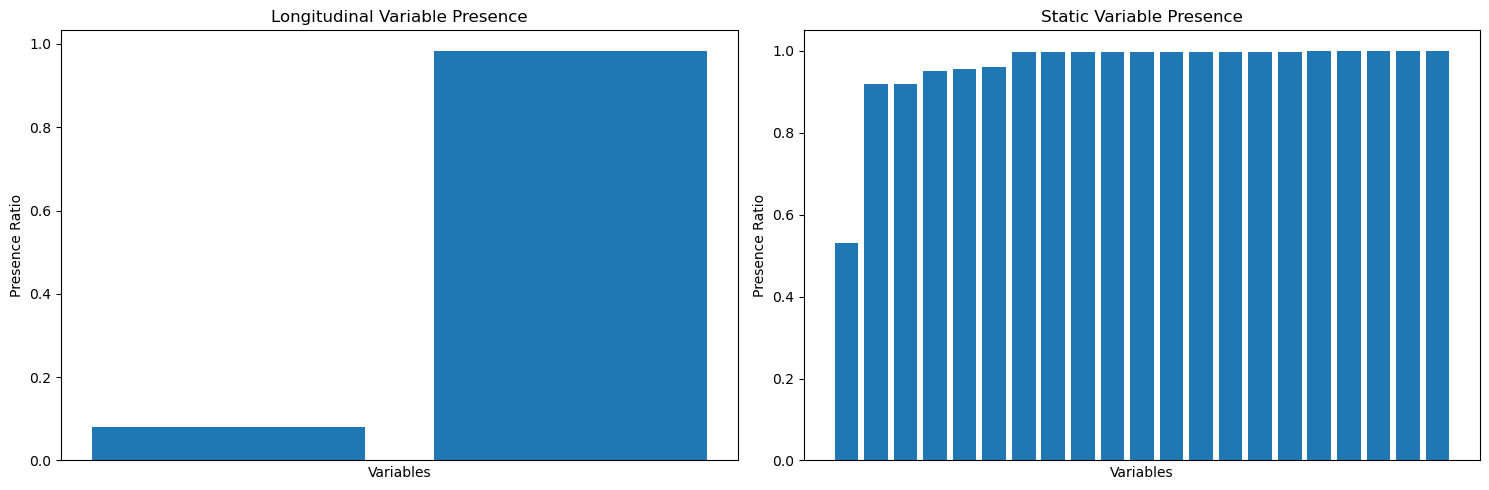

✅ Data processing completed successfully!


In [34]:
# Visualization
plt.figure(figsize=(15, 5))

# Longitudinal data presence
plt.subplot(1, 2, 1)
long_presence_sorted = long_presence.sort_values()
plt.bar(range(len(long_presence_sorted)), long_presence_sorted.values)
plt.title('Longitudinal Variable Presence')
plt.xlabel('Variables')
plt.ylabel('Presence Ratio')
plt.xticks([])

# Static data presence
plt.subplot(1, 2, 2)
static_presence_sorted = static_presence.sort_values()
plt.bar(range(len(static_presence_sorted)), static_presence_sorted.values)
plt.title('Static Variable Presence')
plt.xlabel('Variables')
plt.ylabel('Presence Ratio')
plt.xticks([])

plt.tight_layout()
plt.show()

print("✅ Data processing completed successfully!") 

In [35]:
sns.set(style="whitegrid")

# ---- PARAMETERS ----
N_PATIENTS_SAMPLE = 100
N_PATIENTS_MISSING_HEATMAP = 50

# ---- LONGITUDINAL TRAJECTORIES ----
def plot_longitudinal_trajectories(df_long, vars=['psa']):
    sampled_patients = df_long['PATIENT_ID'].dropna().unique()[:N_PATIENTS_SAMPLE]
    df_subset = df_long[df_long['PATIENT_ID'].isin(sampled_patients)]

    for var in vars:
        if var in df_long.columns:
            plt.figure(figsize=(12, 5))
            sns.lineplot(data=df_subset, x='START_DATE', y=var, hue='PATIENT_ID', marker="o", legend=False)
            plt.title(f"{var.upper()} Trajectories for {N_PATIENTS_SAMPLE} Patients")
            plt.xlabel("Date")
            plt.ylabel(var.upper())
            plt.xticks(rotation=45)
            plt.tight_layout()
            plt.show()

# ---- STATIC DISTRIBUTIONS ----
def plot_static_distributions(df_static, features=['Current Age', 'Sex', 'Stage (Highest Recorded)']):
    """
    Plot distributions of static features using Matplotlib subplots
    """
    n = len(features)
    plt.figure(figsize=(5 * n, 4))

    for i, feature in enumerate(features, 1):
        plt.subplot(1, n, i)
        if df_static[feature].nunique() < 10:
            counts = df_static[feature].value_counts()
            plt.bar(range(len(counts)), counts.values)
            plt.xticks(range(len(counts)), counts.index.astype(str), rotation=45)
            plt.ylabel('Count')
        else:
            plt.hist(df_static[feature].dropna(), bins=20, edgecolor='black', alpha=0.7)
            plt.ylabel('Frequency')
        plt.title(feature)
        plt.xlabel(feature)

    plt.tight_layout()
    plt.show()

# ---- MISSINGNESS (SIDE-BY-SIDE BAR PLOTS) ----
def plot_presence_side_by_side(df_long, df_static):
    """
    Bar plots of variable presence for longitudinal and static data
    """
    long_vars_to_analyze = [col for col in df_long.columns if col not in ['PATIENT_ID', 'START_DATE']]
    long_presence = (~df_long[long_vars_to_analyze].isna()).mean().sort_values()
    static_presence = (~df_static.isna()).mean().sort_values()

    plt.figure(figsize=(15, 5))

    plt.subplot(1, 2, 1)
    plt.bar(range(len(long_presence)), long_presence.values)
    plt.title('Longitudinal Variable Presence')
    plt.xlabel('Variables')
    plt.ylabel('Presence Ratio')
    plt.xticks([])

    plt.subplot(1, 2, 2)
    plt.bar(range(len(static_presence)), static_presence.values)
    plt.title('Static Variable Presence')
    plt.xlabel('Variables')
    plt.ylabel('Presence Ratio')
    plt.xticks([])

    plt.tight_layout()
    plt.show()

    print("✅ Presence visualization completed successfully!")

def plot_missing_data_heatmap(df_long, df_static, max_vars=20):
    """
    Create heatmaps showing missing data patterns
    """
    fig, axes = plt.subplots(1, 2, figsize=(18, 5))
    
    # Longitudinal missing data heatmap
    long_missing = df_long.isna()
    long_vars_to_analyze = [col for col in df_long.columns if col not in ['PATIENT_ID', 'START_DATE']]
    long_missing = long_missing[long_vars_to_analyze]
    long_missing_pct = long_missing.sum() / len(long_missing) * 100
    
    # Select top variables with most missing data
    top_long_vars = long_missing_pct.nlargest(max_vars).index
    long_subset = long_missing[top_long_vars]
    
    # Create patient-level missing pattern (sample of patients)
    sample_patients = df_long['PATIENT_ID'].unique()[:N_PATIENTS_MISSING_HEATMAP]
    long_patient_missing = long_subset[df_long['PATIENT_ID'].isin(sample_patients)]
    
    sns.heatmap(long_patient_missing.T, 
                cbar_kws={'label': 'Missing'}, 
                ax=axes[0], 
                cmap='Reds',
                yticklabels=True,
                xticklabels=False)
    axes[0].set_title('Longitudinal Data Missing Patterns (Sample Patients)')
    axes[0].set_ylabel('Variables')
    
    # Static missing data heatmap
    static_missing = df_static.isna()
    static_missing_pct = static_missing.sum() / len(static_missing) * 100
    
    # Select variables with missing data
    vars_with_missing = static_missing_pct[static_missing_pct > 0].index
    if len(vars_with_missing) > 0:
        static_subset = static_missing[vars_with_missing]
        sns.heatmap(static_subset.T, 
                    cbar_kws={'label': 'Missing'}, 
                    ax=axes[1], 
                    cmap='Reds',
                    yticklabels=True,
                    xticklabels=False)
        axes[1].set_title('Static Data Missing Patterns')
        axes[1].set_ylabel('Variables')
    
    plt.tight_layout()
    plt.show()

# ---- VISIT PATTERNS ----
def plot_patient_visit_summary(df_long):
    visits = df_long.groupby('PATIENT_ID')['START_DATE'].count()
    plt.figure(figsize=(8, 4))
    plt.hist(visits, bins=20, edgecolor='black', alpha=0.7)
    plt.title("Distribution of Visits per Patient")
    plt.xlabel("Number of Visits")
    plt.ylabel("Patients")
    plt.tight_layout()
    plt.show()
    print(f"Avg visits: {visits.mean():.1f}, Max: {visits.max()}, Min: {visits.min()}")

# ---- CORRELATION ANALYSIS ----
def plot_correlation(df_static, df_long):
    """
    Plot correlation heatmap between static and longitudinal variables
    """
    # Get numeric static variables
    df_static_num = df_static.select_dtypes(include=np.number)
    
    # Get numeric longitudinal variables and compute patient means
    long_vars_to_analyze = [col for col in df_long.columns if col not in ['PATIENT_ID', 'START_DATE']]
    df_long_num = df_long[long_vars_to_analyze].select_dtypes(include=np.number)
    
    if not df_long_num.empty:
        df_long_mean = df_long.groupby('PATIENT_ID')[df_long_num.columns].mean()
        
        # Combine static and longitudinal data
        df_combined = pd.merge(df_static_num, df_long_mean, 
                              left_index=True, right_index=True, how='inner')
        
        # Compute correlation
        corr = df_combined.corr()
        
        # Create mask for upper triangle
        mask = np.triu(np.ones_like(corr, dtype=bool))
        
        plt.figure(figsize=(12, 10))
        sns.heatmap(corr, mask=mask, cmap='coolwarm', center=0, square=True, 
                   annot=True, fmt='.2f', cbar_kws={'shrink': 0.8})
        plt.title("Correlation Heatmap: Static vs Longitudinal Variables")
        plt.tight_layout()
        plt.show()
    else:
        print("No numeric longitudinal variables found for correlation analysis")

# ---- DATA QUALITY DASHBOARD ----
def create_data_quality_dashboard(df_long, df_static):
    """
    Create a comprehensive data quality dashboard
    """
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    
    # 1. Longitudinal data presence
    long_vars_to_analyze = [col for col in df_long.columns if col not in ['PATIENT_ID', 'START_DATE']]
    long_presence = (~df_long[long_vars_to_analyze].isna()).mean().sort_values()
    axes[0, 0].bar(range(len(long_presence)), long_presence.values)
    axes[0, 0].set_title('Longitudinal Variable Presence')
    axes[0, 0].set_ylabel('Presence Ratio')
    
    # 2. Static data presence
    static_presence = (~df_static.isna()).mean().sort_values()
    axes[0, 1].bar(range(len(static_presence)), static_presence.values)
    axes[0, 1].set_title('Static Variable Presence')
    axes[0, 1].set_ylabel('Presence Ratio')
    
    # 3. Visit distribution
    visits = df_long.groupby('PATIENT_ID')['START_DATE'].count()
    axes[0, 2].hist(visits, bins=20, edgecolor='black', alpha=0.7)
    axes[0, 2].set_title('Visits per Patient')
    axes[0, 2].set_xlabel('Number of Visits')
    axes[0, 2].set_ylabel('Patients')
    
    # 4. Time span distribution
    time_spans = df_long.groupby('PATIENT_ID')['START_DATE'].agg(['min', 'max'])
    time_spans['span'] = time_spans['max'] # - time_spans['min']
    axes[1, 0].hist(time_spans['span'], bins=20, edgecolor='black', alpha=0.7)
    axes[1, 0].set_title('Patient Time Span')
    axes[1, 0].set_xlabel('Days')
    axes[1, 0].set_ylabel('Patients')
    
    # 5. Age distribution (if available)
    if 'Current Age' in df_static.columns:
        axes[1, 1].hist(df_static['Current Age'].dropna(), bins=20, edgecolor='black', alpha=0.7)
        axes[1, 1].set_title('Age Distribution')
        axes[1, 1].set_xlabel('Age')
        axes[1, 1].set_ylabel('Patients')
    else:
        axes[1, 1].text(0.5, 0.5, 'Age data not available', ha='center', va='center', transform=axes[1, 1].transAxes)
        axes[1, 1].set_title('Age Distribution')
    
    # 6. Cancer stage distribution (if available)
    if 'Stage (Highest Recorded)' in df_static.columns:
        stage_counts = df_static['Stage (Highest Recorded)'].value_counts()
        axes[1, 2].bar(range(len(stage_counts)), stage_counts.values)
        axes[1, 2].set_title('Cancer Stage Distribution')
        axes[1, 2].set_xlabel('Stage')
        axes[1, 2].set_ylabel('Patients')
        axes[1, 2].set_xticks(range(len(stage_counts)))
        axes[1, 2].set_xticklabels(stage_counts.index, rotation=45)
    else:
        axes[1, 2].text(0.5, 0.5, 'Stage data not available', ha='center', va='center', transform=axes[1, 2].transAxes)
        axes[1, 2].set_title('Cancer Stage Distribution')
    
    plt.tight_layout()
    plt.show()
    
    # Print summary statistics
    print("=== DATA QUALITY SUMMARY ===")
    print(f"Total patients: {df_static.shape[0]}")
    print(f"Longitudinal records: {len(df_long)}")
    print(f"Longitudinal variables: {len(long_vars_to_analyze)}")
    print(f"Static variables: {df_static.shape[1]}")
    print(f"Average visits per patient: {visits.mean():.1f}")
    print(time_spans['span'])
    print(f"Time span range: {time_spans['span'].min():.0f} to {time_spans['span'].max():.0f} days")

# ---- WRAPPER ----
def analyze_msk_data(df_long, df_static):
    """
    Comprehensive analysis of MSK Chord data
    """
    print("📈 Longitudinal trajectories...")
    plot_longitudinal_trajectories(df_long, vars=['psa', 'cea', 'ca_15', 'ca_19'])

    print("📊 Static feature distributions...")
    plot_static_distributions(df_static, features=['Current Age', 'Stage (Highest Recorded)'])

    print("�� Presence bar plots...")
    plot_presence_side_by_side(df_long, df_static)
    
    print("🔥 Missing data heatmaps...")
    plot_missing_data_heatmap(df_long, df_static, max_vars=20)

    print("📅 Visit patterns...")
    plot_patient_visit_summary(df_long)
    
    print("🔗 Correlation analysis...")
    plot_correlation(df_static, df_long)
    
    print("📊 Data quality dashboard...")
    create_data_quality_dashboard(df_long, df_static)
    
    print("✅ MSK data analysis completed!")

📈 Longitudinal trajectories...


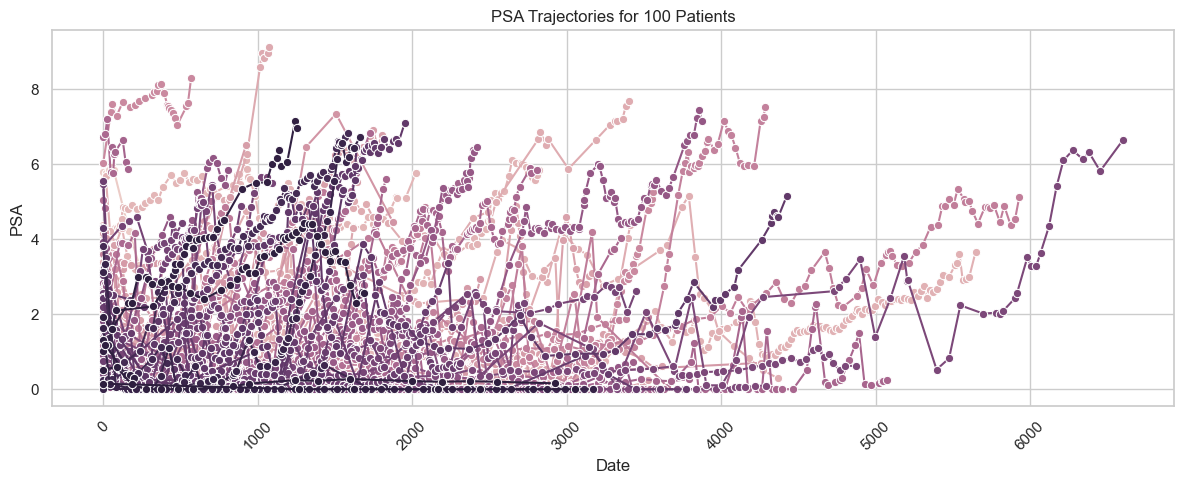

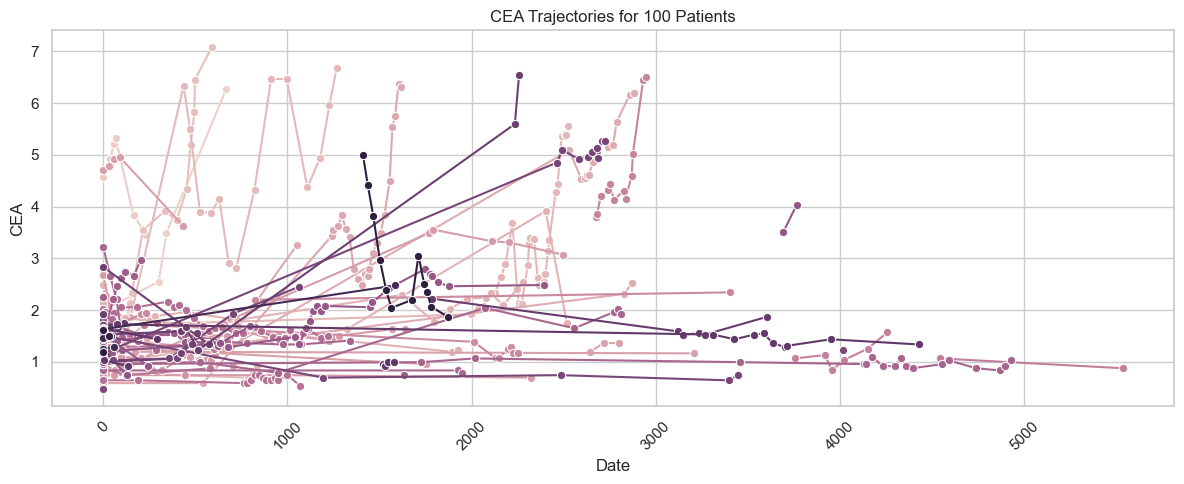

📊 Static feature distributions...


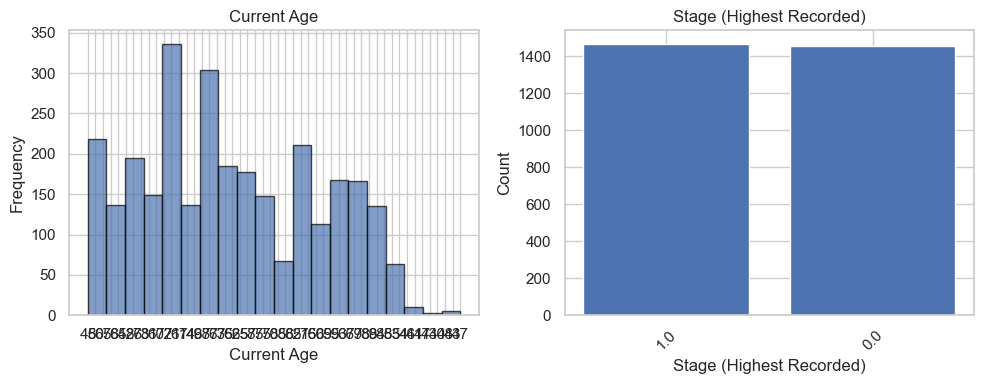

�� Presence bar plots...


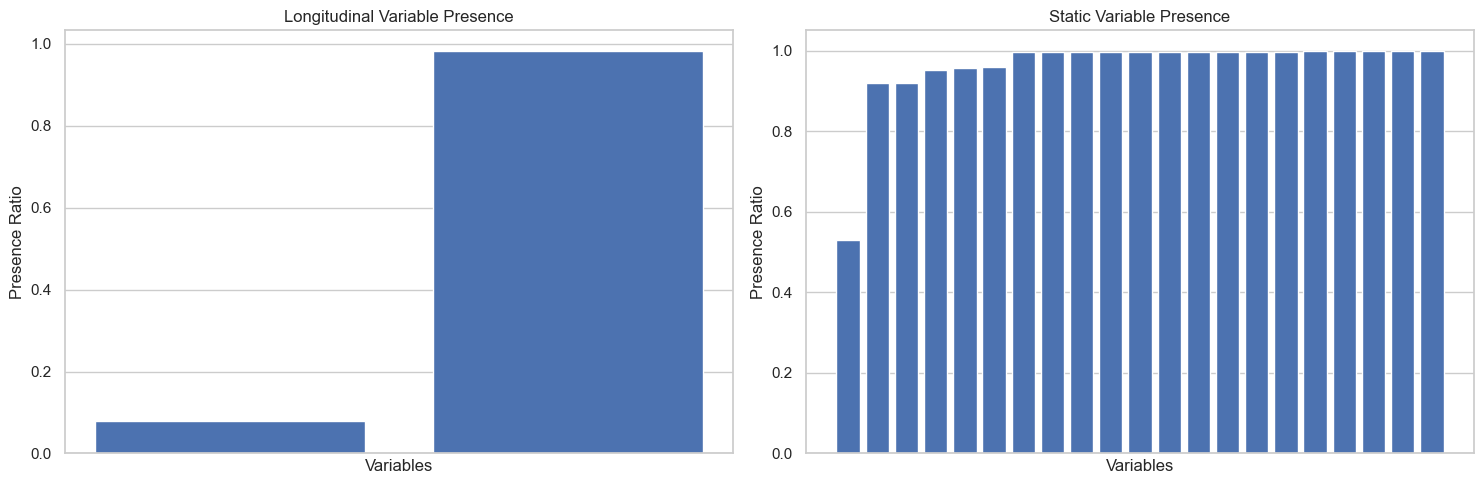

✅ Presence visualization completed successfully!
🔥 Missing data heatmaps...


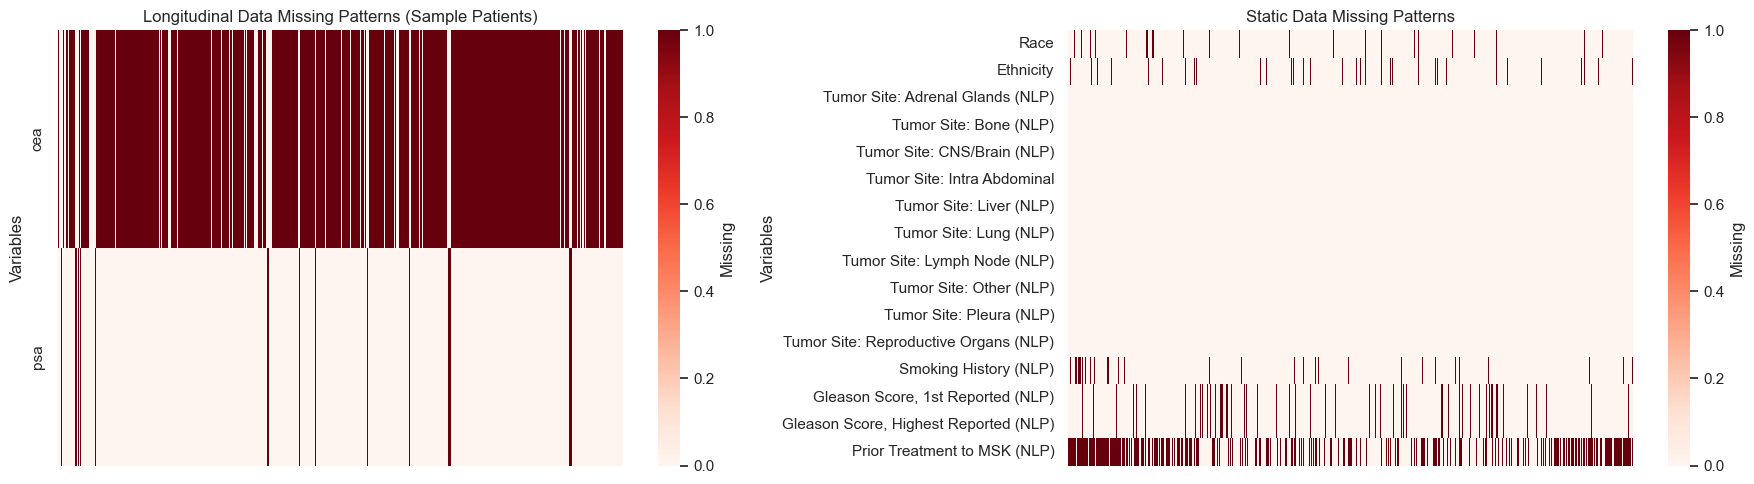

📅 Visit patterns...


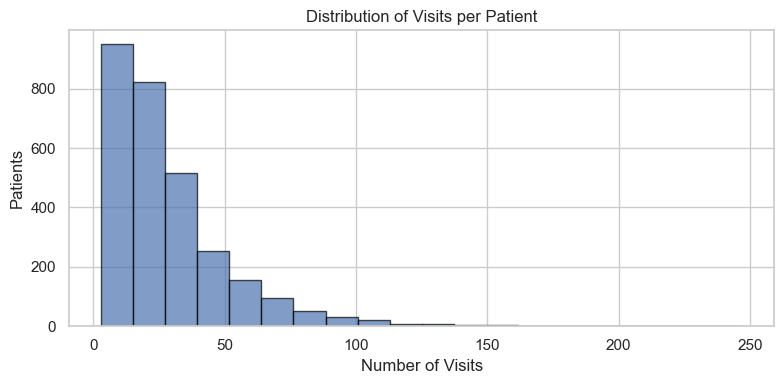

Avg visits: 28.8, Max: 247, Min: 3
🔗 Correlation analysis...


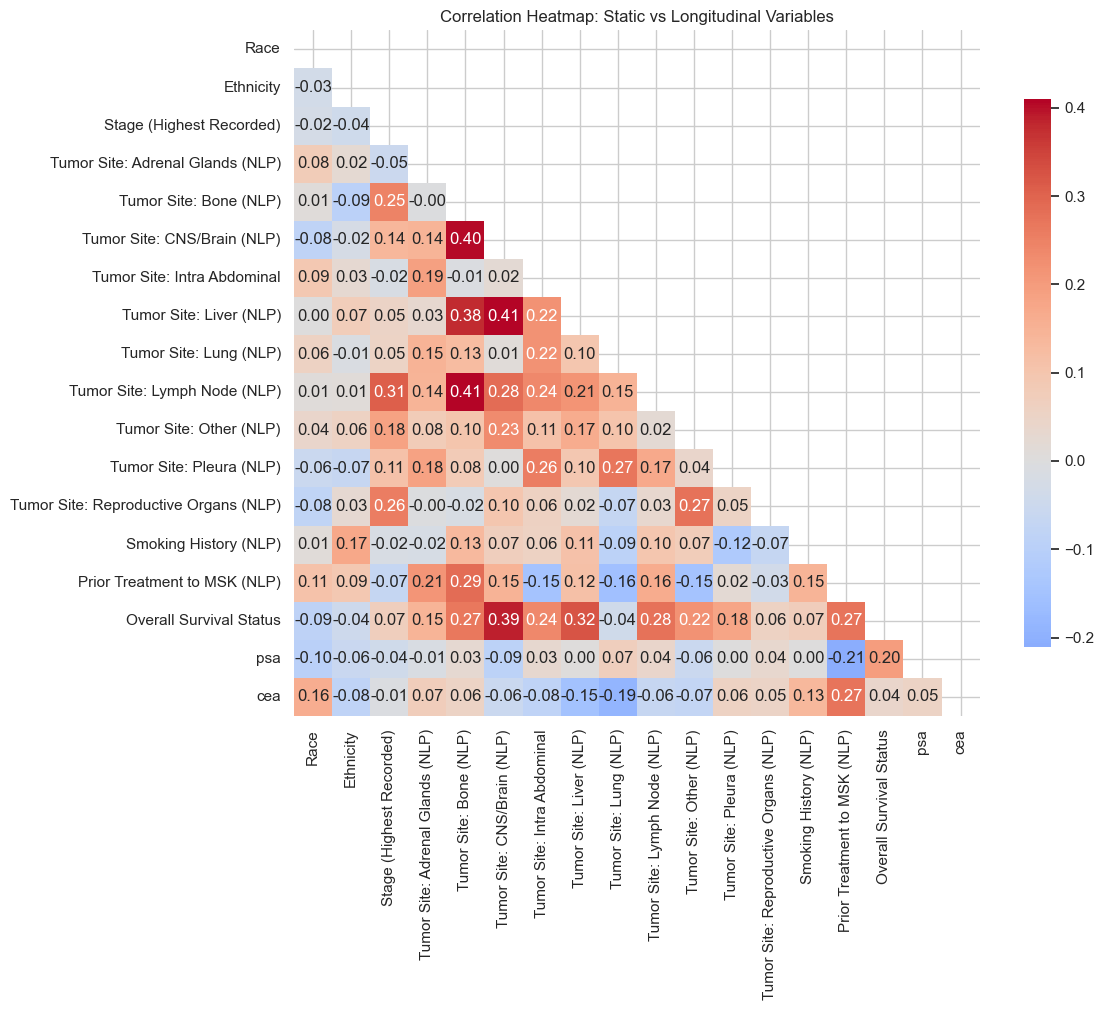

📊 Data quality dashboard...


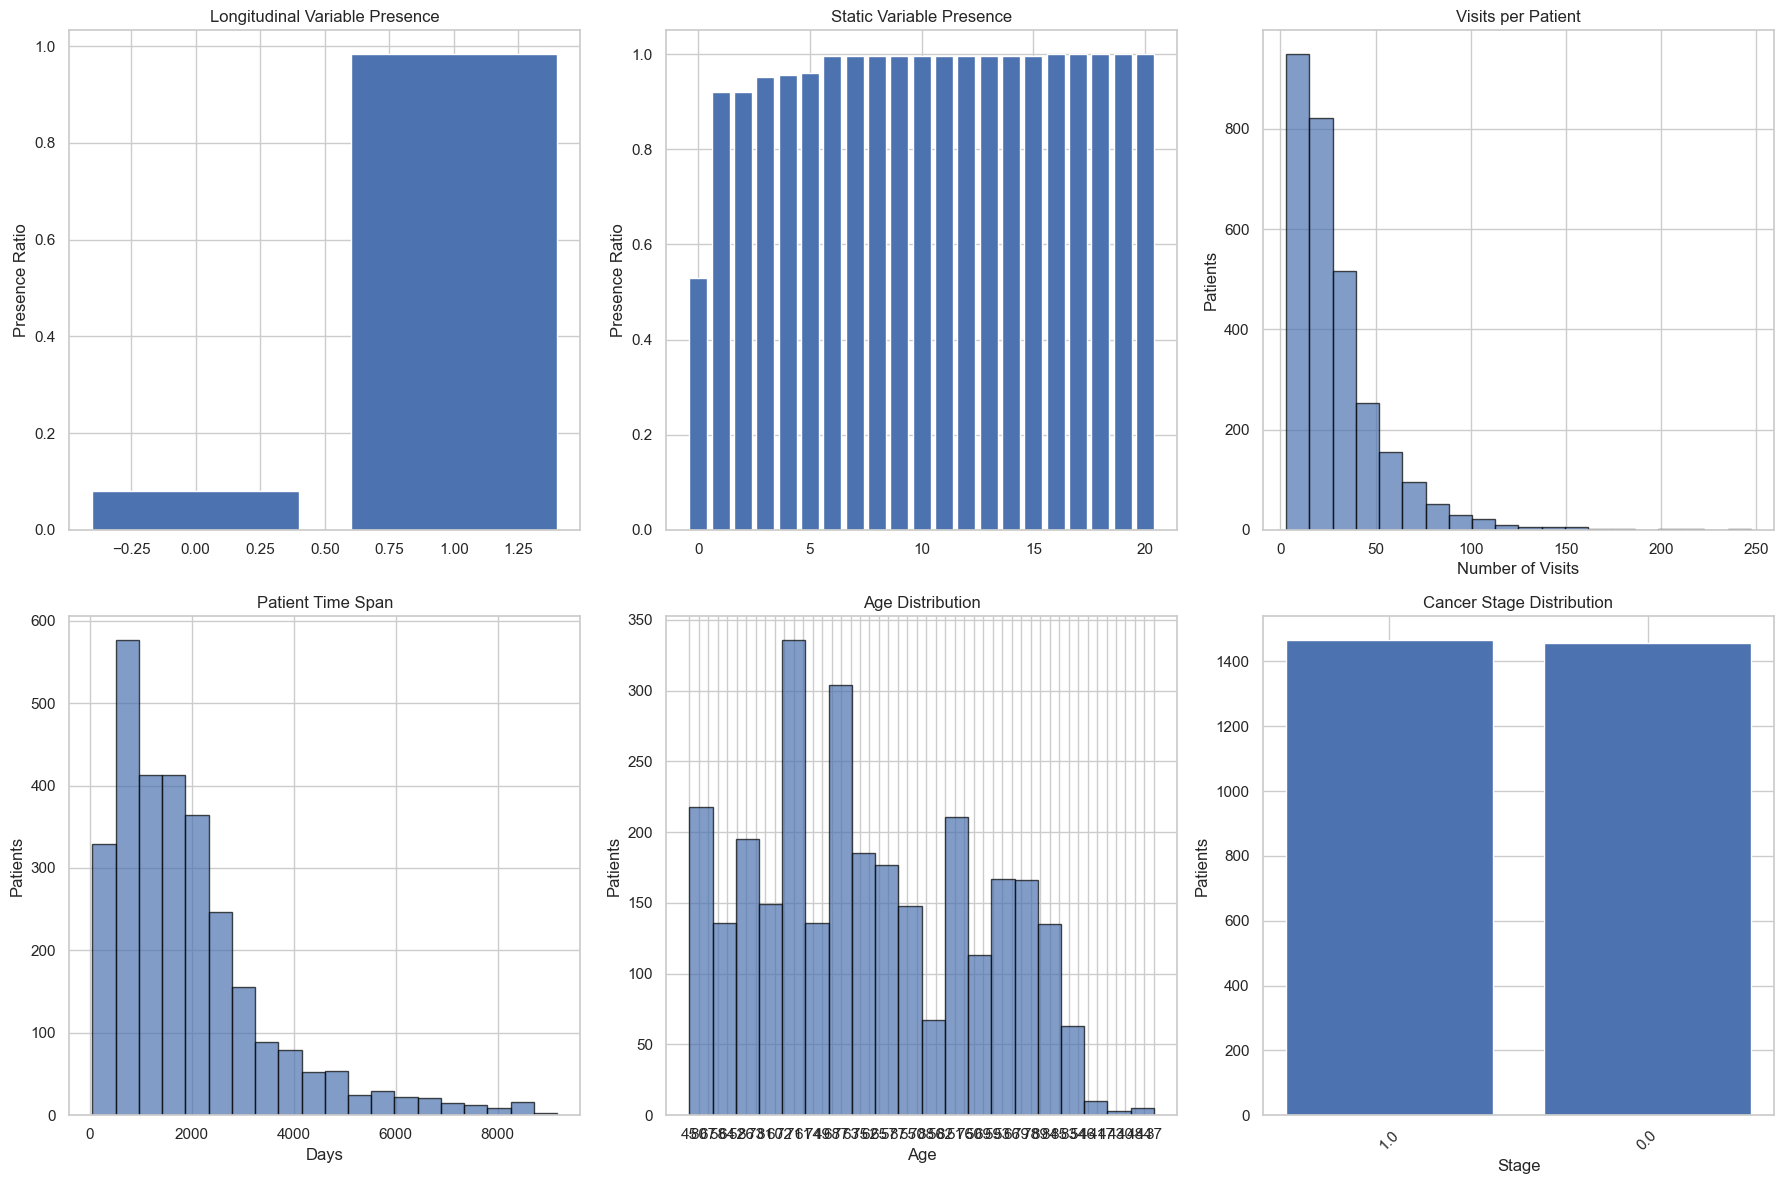

=== DATA QUALITY SUMMARY ===
Total patients: 2924
Longitudinal records: 84336
Longitudinal variables: 2
Static variables: 21
Average visits per patient: 28.8
PATIENT_ID
140       668
197       231
318       588
373      1247
377      1267
         ... 
89403     532
89404    1237
89447     613
89514     195
89592     216
Name: span, Length: 2924, dtype: int64
Time span range: 47 to 9164 days
✅ MSK data analysis completed!


In [36]:
analyze_msk_data(df_long_clean, df_static_final)